# Exploratory Data Analysis — Fake News Classifier
**Prepared by: Md. Roton Ahmed**

## 1. Load and Inspect Data

In [10]:
%pip install pandas numpy matplotlib seaborn nltk scikit-learn gradio joblib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import nltk
from collections import Counter
from nltk.corpus import stopwords
import string

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [12]:
# Load dataset
df = pd.read_csv('../data/fake_and_real_news.csv')

print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nFirst 3 rows:')
df.head(3)

Shape: (9900, 2)

Data Types:
Text     object
label    object
dtype: object

First 3 rows:


,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real


In [13]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum())

print(f'\nDuplicate rows: {df.duplicated().sum()}')

# Drop duplicates and missing if any
df = df.drop_duplicates().dropna()
print(f'\nClean dataset shape: {df.shape}')

Missing values per column:
Text     0
label    0
dtype: int64

Duplicate rows: 35

Clean dataset shape: (9865, 2)


## 2. Label Distribution

Label counts:
label
Fake    5000
Real    4865
Name: count, dtype: int64

Balance ratio: 0.973


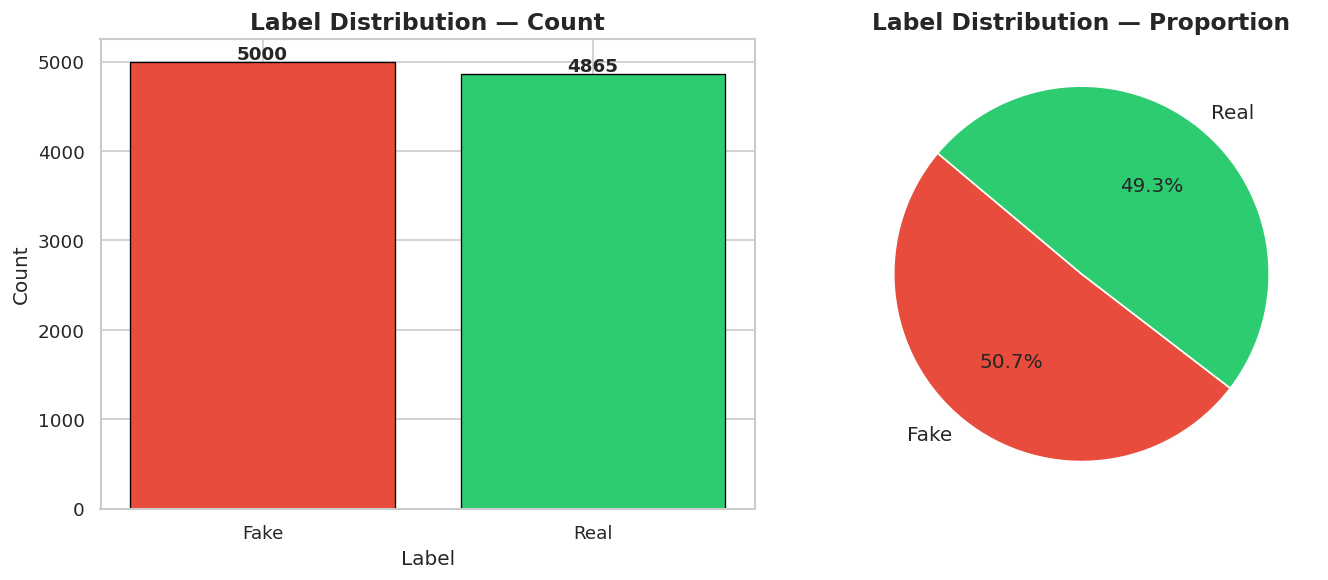


The dataset is balanced — roughly equal Fake and Real articles.


In [14]:
label_counts = df['label'].value_counts()
print('Label counts:')
print(label_counts)
print(f'\nBalance ratio: {label_counts.min()/label_counts.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Label Distribution — Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Label Distribution — Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/label_distribution.png', bbox_inches='tight')
plt.show()
print('\nThe dataset is balanced — roughly equal Fake and Real articles.')

## 3. Text Length Analysis

In [15]:
df['text_length'] = df['Text'].apply(len)
df['word_count']  = df['Text'].apply(lambda x: len(x.split()))

print('Character length stats by label:')
print(df.groupby('label')['text_length'].describe().round(1))
print('\nWord count stats by label:')
print(df.groupby('label')['word_count'].describe().round(1))

Character length stats by label:
        count    mean     std    min     25%     50%     75%      max
label                                                                
Fake   5000.0  2691.3   914.6  316.0  2104.0  2498.0  3103.0  20356.0
Real   4865.0  2477.1  1750.5  219.0   827.0  2390.0  3472.0  29849.0

Word count stats by label:
        count   mean    std   min    25%    50%    75%     max
label                                                         
Fake   5000.0  449.4  149.5  46.0  354.0  419.0  517.0  3927.0
Real   4865.0  394.9  282.3  35.0  133.0  381.0  554.0  5181.0


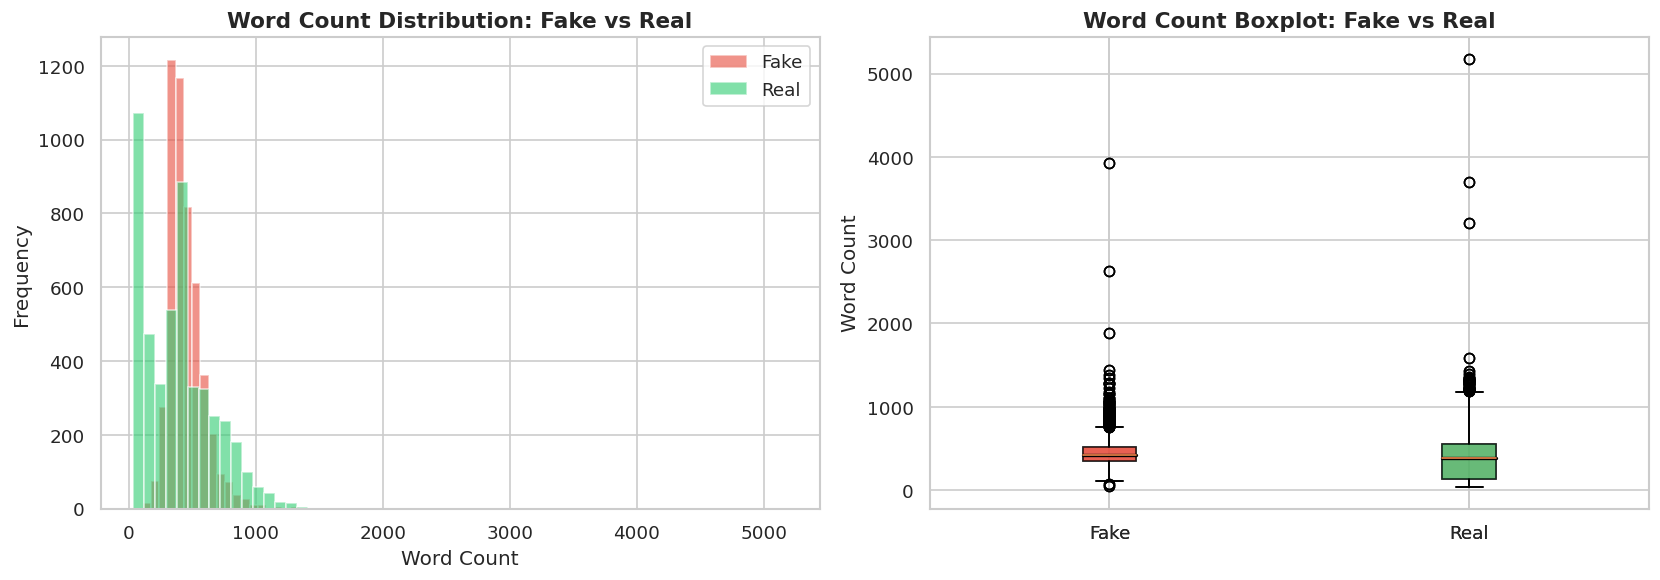


Avg words — Fake: 449 | Real: 395

Fake articles tend to be longer on average.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('Fake', '#e74c3c'), ('Real', '#2ecc71')]:
    subset = df[df['label'] == label]['word_count']
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Word Count Distribution: Fake vs Real', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
fake_wc = df[df['label']=='Fake']['word_count']
real_wc = df[df['label']=='Real']['word_count']
axes[1].boxplot([fake_wc, real_wc], labels=['Fake', 'Real'],
                patch_artist=True,
                boxprops=dict(facecolor='#e74c3c', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
# Color second box
bplot = axes[1].boxplot([fake_wc, real_wc], labels=['Fake', 'Real'], patch_artist=True)
for patch, color in zip(bplot['boxes'], ['#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Word Count Boxplot: Fake vs Real', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('../screenshots/text_length_analysis.png', bbox_inches='tight')
plt.show()

avg_fake = fake_wc.mean()
avg_real = real_wc.mean()
print(f'\nAvg words — Fake: {avg_fake:.0f} | Real: {avg_real:.0f}')
winner = 'Fake' if avg_fake > avg_real else 'Real'
print(f'\n{winner} articles tend to be longer on average.')

## 4. Most Common Words (After Stopword Removal)

In [17]:
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        text = text.lower().translate(str.maketrans('', '', string.punctuation))
        words += [w for w in text.split() if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

fake_words = get_top_words(df[df['label']=='Fake']['Text'])
real_words = get_top_words(df[df['label']=='Real']['Text'])

print('Top 5 Fake words:', fake_words[:5])
print('Top 5 Real words:', real_words[:5])

Top 5 Fake words: [('trump', 36475), ('donald', 7614), ('people', 6983), ('president', 6523), ('said', 6413)]
Top 5 Real words: [('said', 22434), ('trump', 16596), ('would', 8923), ('house', 8388), ('president', 8316)]


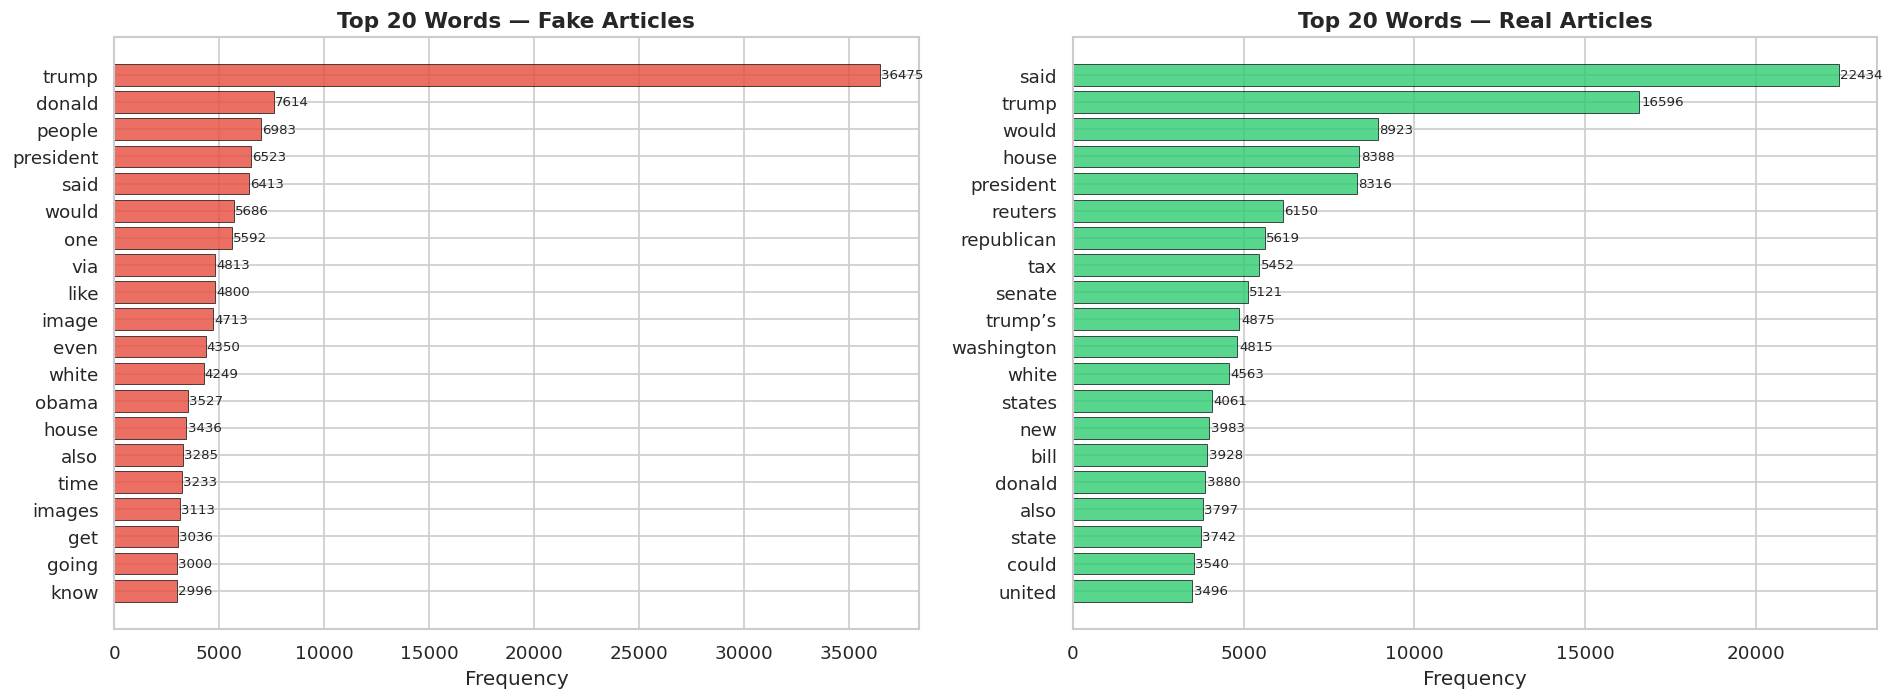


EDA complete! Key observation: Fake articles use more emotionally charged language.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, word_freq, label, color in [
    (axes[0], fake_words, 'Fake', '#e74c3c'),
    (axes[1], real_words, 'Real', '#2ecc71')
]:
    words, counts = zip(*word_freq)
    bars = ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Top 20 Words — {label} Articles', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    for bar, count in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../screenshots/top_words.png', bbox_inches='tight')
plt.show()
print('\nEDA complete! Key observation: Fake articles use more emotionally charged language.')

## EDA Summary

| Finding | Detail |
|---|---|
| Dataset shape | ~9,900 rows × 2 columns |
| Class balance | Roughly balanced (Fake ≈ Real) |
| Text length | Fake articles tend to be longer |
| Vocabulary | Fake: emotional words; Real: formal/factual language |